In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset uploaded successfully!")
print("File name:", file_name)

Saving CSE_Curriculum_Industry_Skill_Gap_Dataset.csv to CSE_Curriculum_Industry_Skill_Gap_Dataset.csv
Dataset uploaded successfully!
File name: CSE_Curriculum_Industry_Skill_Gap_Dataset.csv


In [6]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (20, 6)

First 5 Records:


,Skill,Curriculum_Level,Industry_Required_Level,Alignment_Score,Industry_Priority,Skill_Category
0,Python,4,5,0.90,High,Programming
1,Java,4,4,0.75,Medium,Programming
2,C/C++,5,3,0.55,Medium,Programming
3,SQL,4,5,0.90,High,Database
4,Data Structures,5,5,0.95,High,Core CS



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Skill                    20 non-null     object 
 1   Curriculum_Level         20 non-null     int64  
 2   Industry_Required_Level  20 non-null     int64  
 3   Alignment_Score          20 non-null     float64
 4   Industry_Priority        20 non-null     object 
 5   Skill_Category           20 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.1+ KB


In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Skill                      0
Curriculum_Level           0
Industry_Required_Level    0
Alignment_Score            0
Industry_Priority          0
Skill_Category             0
dtype: int64

Duplicate Rows:
0


In [8]:
df["Skill_Gap"] = (
    df["Industry_Required_Level"] - df["Curriculum_Level"]
)

print("Skill Gap calculated successfully!")

display(
    df[[
        "Skill",
        "Curriculum_Level",
        "Industry_Required_Level",
        "Skill_Gap"
    ]]
)

Skill Gap calculated successfully!


,Skill,Curriculum_Level,Industry_Required_Level,Skill_Gap
0,Python,4,5,1
1,Java,4,4,0
2,C/C++,5,3,-2
3,SQL,4,5,1
4,Data Structures,5,5,0
5,Algorithms,5,5,0
6,DBMS,4,5,1
7,Operating Systems,4,4,0
8,Computer Networks,4,4,0
9,Software Engineering,4,4,0


In [9]:
def classify_gap(gap):
    if gap >= 2:
        return "Critical Gap"
    elif gap == 1:
        return "Moderate Gap"
    else:
        return "No Major Gap"

df["Gap_Status"] = df["Skill_Gap"].apply(classify_gap)

display(
    df[[
        "Skill",
        "Curriculum_Level",
        "Industry_Required_Level",
        "Skill_Gap",
        "Gap_Status"
    ]]
)

,Skill,Curriculum_Level,Industry_Required_Level,Skill_Gap,Gap_Status
0,Python,4,5,1,Moderate Gap
1,Java,4,4,0,No Major Gap
2,C/C++,5,3,-2,No Major Gap
3,SQL,4,5,1,Moderate Gap
4,Data Structures,5,5,0,No Major Gap
5,Algorithms,5,5,0,No Major Gap
6,DBMS,4,5,1,Moderate Gap
7,Operating Systems,4,4,0,No Major Gap
8,Computer Networks,4,4,0,No Major Gap
9,Software Engineering,4,4,0,No Major Gap


In [10]:
def decision(row):
    if row["Skill_Gap"] >= 2 and row["Industry_Priority"] == "High":
        return "Immediate Training Required"

    elif row["Skill_Gap"] == 1 and row["Industry_Priority"] == "High":
        return "Priority Improvement Required"

    elif row["Skill_Gap"] >= 1:
        return "Recommended Improvement"

    else:
        return "Maintain Current Level"

df["Decision"] = df.apply(decision, axis=1)

display(
    df[[
        "Skill",
        "Skill_Gap",
        "Industry_Priority",
        "Decision"
    ]]
)

,Skill,Skill_Gap,Industry_Priority,Decision
0,Python,1,High,Priority Improvement Required
1,Java,0,Medium,Maintain Current Level
2,C/C++,-2,Medium,Maintain Current Level
3,SQL,1,High,Priority Improvement Required
4,Data Structures,0,High,Maintain Current Level
5,Algorithms,0,High,Maintain Current Level
6,DBMS,1,High,Priority Improvement Required
7,Operating Systems,0,Medium,Maintain Current Level
8,Computer Networks,0,Medium,Maintain Current Level
9,Software Engineering,0,Medium,Maintain Current Level


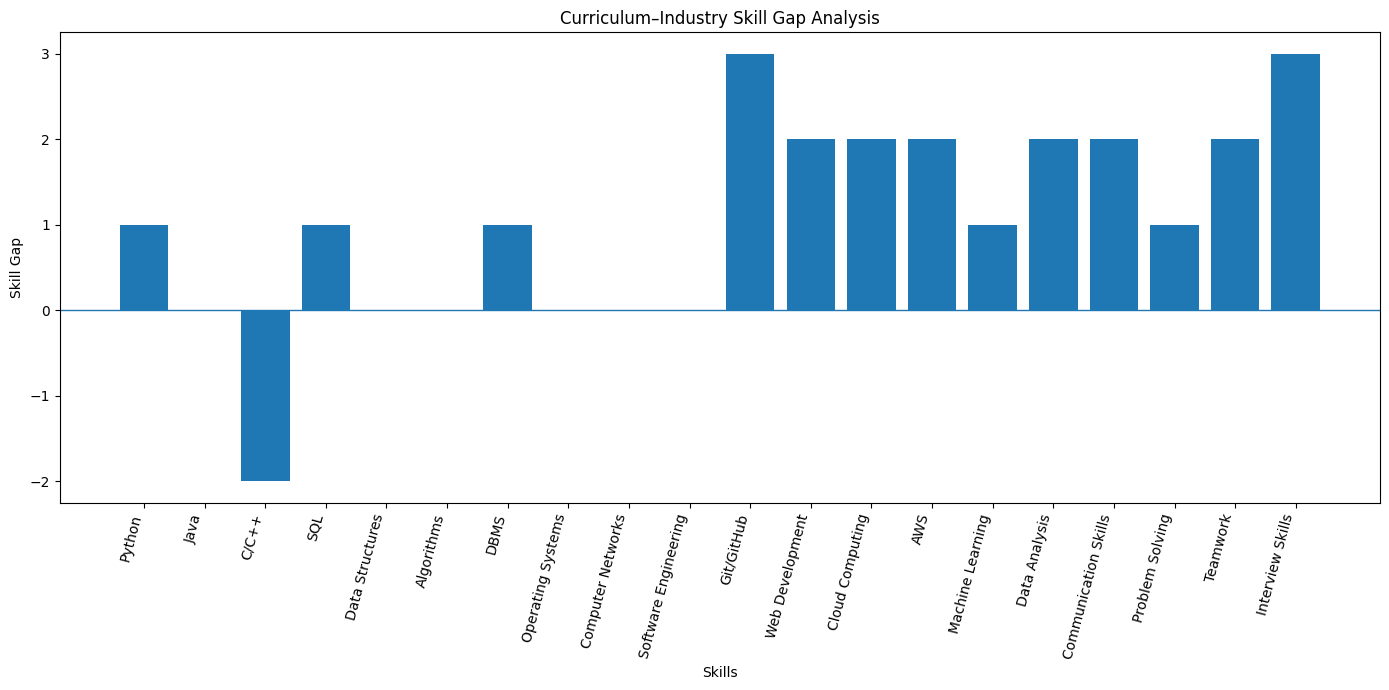

In [11]:
plt.figure(figsize=(14, 7))

plt.bar(
    df["Skill"],
    df["Skill_Gap"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Skills")
plt.ylabel("Skill Gap")
plt.title("Curriculum–Industry Skill Gap Analysis")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

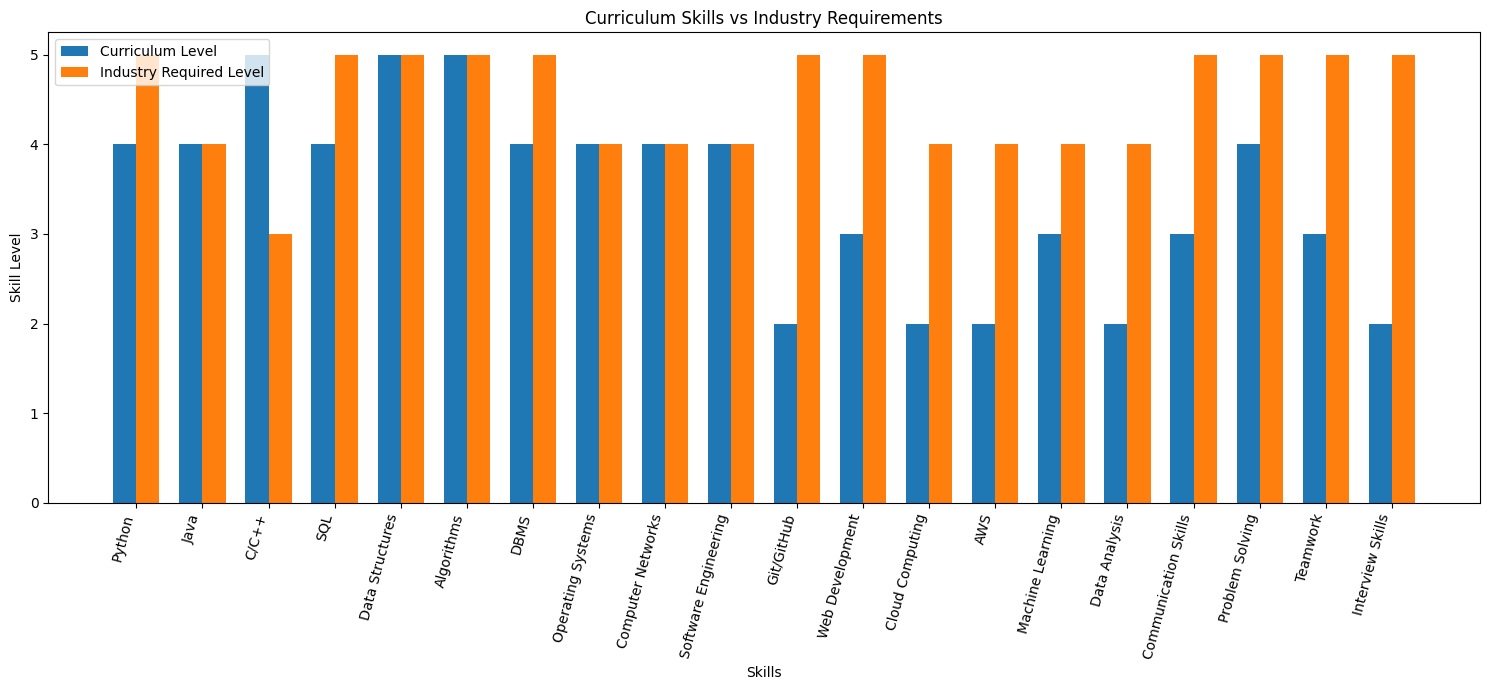

In [12]:
x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(15, 7))

plt.bar(
    x - width/2,
    df["Curriculum_Level"],
    width,
    label="Curriculum Level"
)

plt.bar(
    x + width/2,
    df["Industry_Required_Level"],
    width,
    label="Industry Required Level"
)

plt.xlabel("Skills")
plt.ylabel("Skill Level")
plt.title("Curriculum Skills vs Industry Requirements")

plt.xticks(
    x,
    df["Skill"],
    rotation=75,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

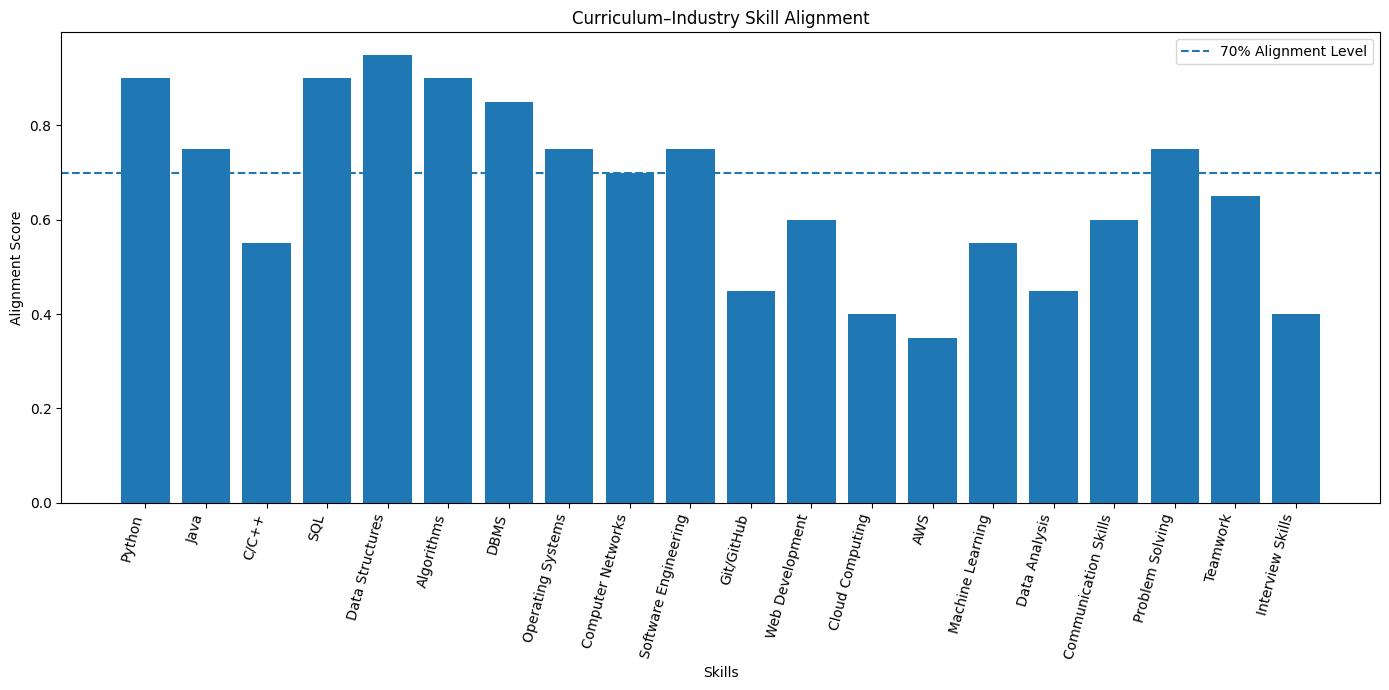

In [13]:
plt.figure(figsize=(14, 7))

plt.bar(
    df["Skill"],
    df["Alignment_Score"]
)

plt.axhline(
    y=0.70,
    linestyle="--",
    label="70% Alignment Level"
)

plt.xlabel("Skills")
plt.ylabel("Alignment Score")
plt.title("Curriculum–Industry Skill Alignment")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
category_analysis = df.groupby("Skill_Category").agg({
    "Curriculum_Level": "mean",
    "Industry_Required_Level": "mean",
    "Alignment_Score": "mean",
    "Skill_Gap": "mean"
}).round(2)

display(category_analysis)

,Curriculum_Level,Industry_Required_Level,Alignment_Score,Skill_Gap
Skill_Category,,,,
AI/Data,2.50,4.0,0.50,1.50
Cloud,2.00,4.0,0.38,2.00
Core CS,4.50,4.5,0.82,0.00
Database,4.00,5.0,0.88,1.00
Development,3.00,5.0,0.60,2.00
Employability,2.00,5.0,0.40,3.00
Programming,4.33,4.0,0.73,-0.33
Soft Skills,3.33,5.0,0.67,1.67
Software Development,4.00,4.0,0.75,0.00


In [15]:
priority_skills = df[
    (df["Industry_Priority"] == "High") &
    (df["Skill_Gap"] >= 1)
]

print("High-Priority Skills Requiring Improvement:")

display(
    priority_skills[
        [
            "Skill",
            "Curriculum_Level",
            "Industry_Required_Level",
            "Skill_Gap",
            "Alignment_Score",
            "Decision"
        ]
    ].sort_values(
        by="Skill_Gap",
        ascending=False
    )
)

High-Priority Skills Requiring Improvement:


,Skill,Curriculum_Level,Industry_Required_Level,Skill_Gap,Alignment_Score,Decision
10,Git/GitHub,2,5,3,0.45,Immediate Training Required
19,Interview Skills,2,5,3,0.40,Immediate Training Required
11,Web Development,3,5,2,0.60,Immediate Training Required
13,AWS,2,4,2,0.35,Immediate Training Required
15,Data Analysis,2,4,2,0.45,Immediate Training Required
16,Communication Skills,3,5,2,0.60,Immediate Training Required
18,Teamwork,3,5,2,0.65,Immediate Training Required
12,Cloud Computing,2,4,2,0.40,Immediate Training Required
6,DBMS,4,5,1,0.85,Priority Improvement Required
3,SQL,4,5,1,0.90,Priority Improvement Required


In [16]:
decision_summary = df["Decision"].value_counts()

print("Decision Framework Summary:")
display(decision_summary)

Decision Framework Summary:


,count
Decision,
Immediate Training Required,8
Maintain Current Level,7
Priority Improvement Required,4
Recommended Improvement,1


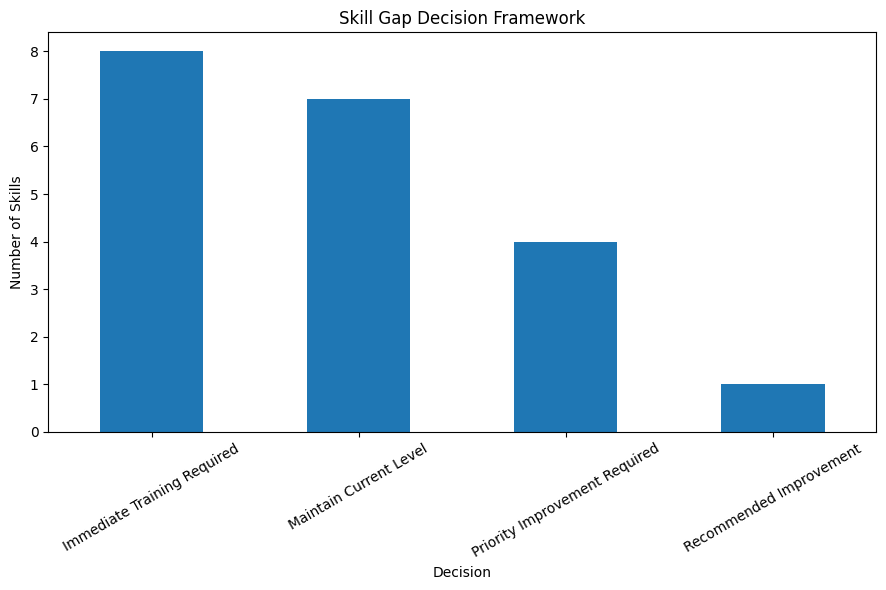

In [17]:
plt.figure(figsize=(9, 6))

decision_summary.plot(
    kind="bar"
)

plt.xlabel("Decision")
plt.ylabel("Number of Skills")
plt.title("Skill Gap Decision Framework")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [18]:
overall_alignment = df["Alignment_Score"].mean()

print(
    "Overall Curriculum–Industry Alignment Score:",
    round(overall_alignment * 100, 2),
    "%"
)

Overall Curriculum–Industry Alignment Score: 66.0 %


In [19]:
print("===== RECOMMENDATIONS =====\n")

for _, row in priority_skills.sort_values(
    by="Skill_Gap",
    ascending=False
).iterrows():

    print(
        f"• {row['Skill']}: "
        f"{row['Decision']}"
    )

===== RECOMMENDATIONS =====

• Git/GitHub: Immediate Training Required
• Interview Skills: Immediate Training Required
• Web Development: Immediate Training Required
• AWS: Immediate Training Required
• Data Analysis: Immediate Training Required
• Communication Skills: Immediate Training Required
• Teamwork: Immediate Training Required
• Cloud Computing: Immediate Training Required
• DBMS: Priority Improvement Required
• SQL: Priority Improvement Required
• Python: Priority Improvement Required
• Problem Solving: Priority Improvement Required


In [20]:
output_file = "CSE_Skill_Gap_Analysis_Results.csv"

df.to_csv(
    output_file,
    index=False
)

print("Analysis completed!")
print("Output file:", output_file)

Analysis completed!
Output file: CSE_Skill_Gap_Analysis_Results.csv


In [21]:
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>